# Full Model Comparison (All Metrics)

This notebook compares `ItemKNN`, `SVD`, and `LightFM` on all implemented metrics using the train split and holdout test split.

Cold-start routing is **not** used here.

In [1]:
from dataclasses import asdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from src.evaluation.pipeline import OfflineRecommenderEvaluator
from src.models.item_knn_model import ItemKNNModel
from src.models.lightfm_model import LightFMHybridModel
from src.models.svd_model import SVDModel

/home/samuel/Documents/data-mining-recommender-systems/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load Train and Holdout Test Split

We use the existing split files from `data/processed/notebook_demo`.

In [2]:
project_root_path = Path.cwd()
if not (project_root_path / "src").exists():
    project_root_path = project_root_path.parent

train_ratings_path = project_root_path / "data" / "processed" / "notebook_demo" / "ratings_train_split.csv"
test_ratings_path = project_root_path / "data" / "processed" / "notebook_demo" / "ratings_validation_split.csv"
movies_features_path = project_root_path / "data" / "processed" / "movies_cleaned.csv"

train_dataframe = pd.read_csv(train_ratings_path)
test_dataframe = pd.read_csv(test_ratings_path)
movies_dataframe = pd.read_csv(movies_features_path)

# Keep only users seen in train because this notebook disables cold-start routing.
known_user_ids = set(train_dataframe["userId"].astype(int).unique().tolist())
test_dataframe = test_dataframe[test_dataframe["userId"].astype(int).isin(known_user_ids)].copy()

print(f"Train rows: {len(train_dataframe)}")
print(f"Test rows (known users only): {len(test_dataframe)}")
print(f"Movies rows: {len(movies_dataframe)}")

Train rows: 95251
Test rows (known users only): 2550
Movies rows: 9742


## Build Models

Hyperparameters are set to practical defaults for notebook runtime.

In [3]:
model_map = {
    "itemknn": ItemKNNModel(),
    "svd": SVDModel(),
    "lightfm": LightFMHybridModel(),
}

evaluator = OfflineRecommenderEvaluator(number_of_recommendations=10, relevance_threshold=4.0)

## Fit and Evaluate

Each model is trained on the train split and evaluated on the holdout test split.

In [4]:
evaluation_rows = []

for model_name, model in model_map.items():
    print(f"Running: {model_name}")

    if model_name == "lightfm":
        model.fit(ratings_dataframe=train_dataframe, movies_dataframe=movies_dataframe)
    else:
        model.fit(ratings_dataframe=train_dataframe)

    evaluation_result = evaluator.evaluate(
        model=model,
        train_dataframe=train_dataframe,
        validation_dataframe=test_dataframe,
        movies_dataframe=movies_dataframe,
        inference_router=None,
    )

    evaluation_row = {"model_name": model_name}
    evaluation_row.update(asdict(evaluation_result))
    evaluation_rows.append(evaluation_row)

metrics_dataframe = pd.DataFrame(evaluation_rows).set_index("model_name")
metrics_dataframe

,rmse_value,mae_value,precision_at_k,recall_at_k,ndcg_at_k,novelty_at_k,diversity_at_k,item_coverage_at_k,intra_list_similarity_at_k,item_to_history_distance_at_k,serendipity_at_k
model_name,,,,,,,,,,,
itemknn,0.857318,0.671706,0.654,0.569424,0.644338,16.421508,0.743929,0.028557,0.256071,0.244341,0.244341
svd,0.840604,0.669088,0.690,0.581204,0.683569,9.090718,0.703597,0.003648,0.296403,0.160045,0.160045
lightfm,0.961016,0.791624,0.590,0.522113,0.565943,15.332794,0.374222,0.001042,0.625778,0.264944,0.264944


## Save Comparison Table

This writes the full table so it can be reused in your report.

In [5]:
output_path = project_root_path / "data" / "processed" / "notebook_demo" / "model_comparison_all_metrics.csv"
metrics_dataframe.reset_index().to_csv(output_path, index=False)
print(f"Saved comparison table to: {output_path}")

Saved comparison table to: /home/samuel/Documents/data-mining-recommender-systems/data/processed/notebook_demo/model_comparison_all_metrics.csv


## Graph 1: Accuracy Metrics

Lower is better for RMSE and MAE.

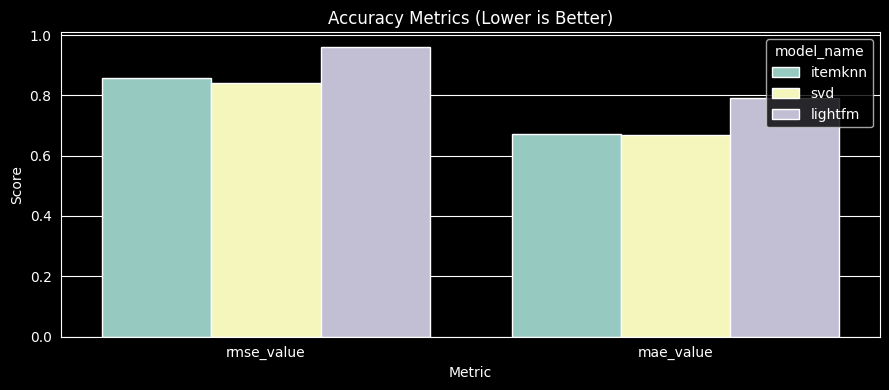

In [6]:
accuracy_columns = ["rmse_value", "mae_value"]
plot_dataframe = (
    metrics_dataframe[accuracy_columns].reset_index().melt(id_vars="model_name", var_name="metric", value_name="value")
)

plt.figure(figsize=(9, 4))
sns.barplot(data=plot_dataframe, x="metric", y="value", hue="model_name")
plt.title("Accuracy Metrics (Lower is Better)")
plt.xlabel("Metric")
plt.ylabel("Score")
plt.tight_layout()
plt.show()

## Graph 2: Ranking Metrics

Higher is better for Precision, Recall, and NDCG.

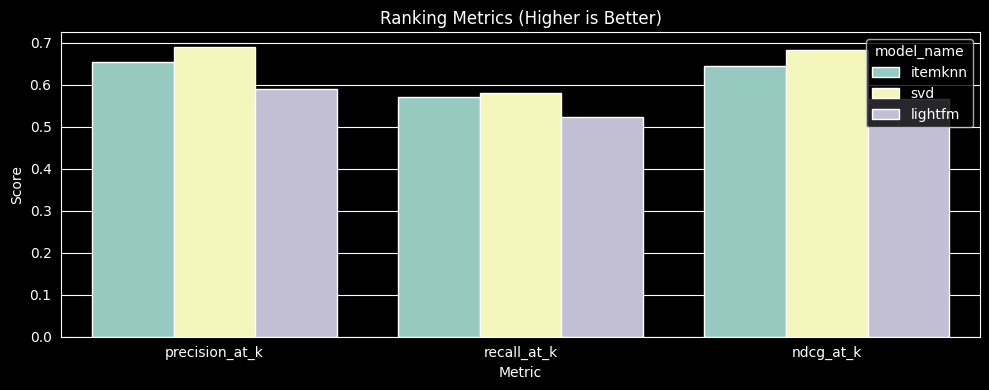

In [7]:
ranking_columns = ["precision_at_k", "recall_at_k", "ndcg_at_k"]
plot_dataframe = (
    metrics_dataframe[ranking_columns].reset_index().melt(id_vars="model_name", var_name="metric", value_name="value")
)

plt.figure(figsize=(10, 4))
sns.barplot(data=plot_dataframe, x="metric", y="value", hue="model_name")
plt.title("Ranking Metrics (Higher is Better)")
plt.xlabel("Metric")
plt.ylabel("Score")
plt.tight_layout()
plt.show()

## Graph 3: Beyond-Accuracy Metrics

This graph compares novelty, diversity, coverage, similarity, history distance, and serendipity.

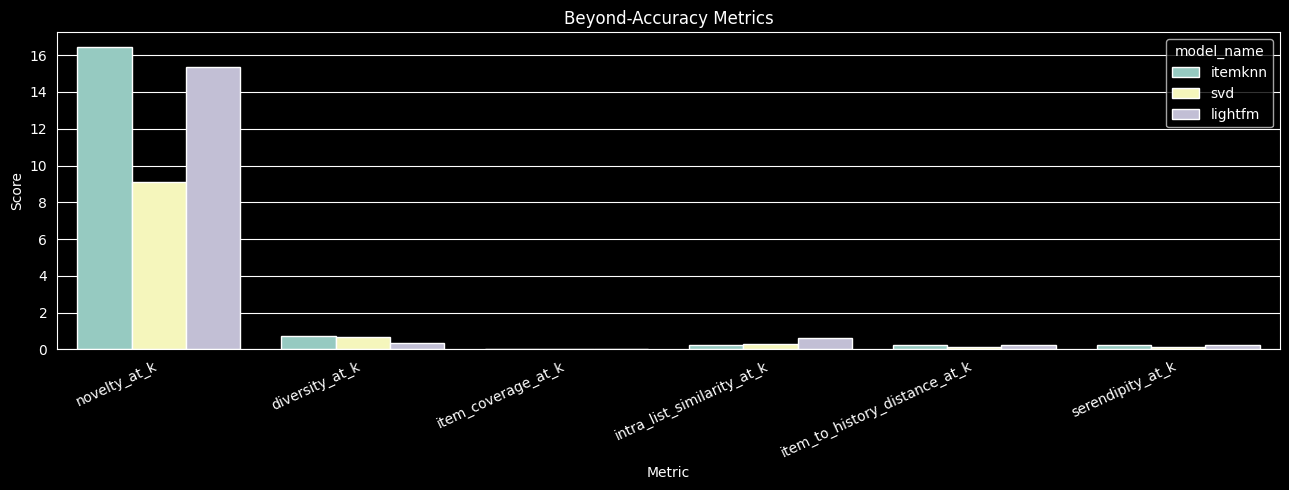

In [8]:
beyond_columns = [
    "novelty_at_k",
    "diversity_at_k",
    "item_coverage_at_k",
    "intra_list_similarity_at_k",
    "item_to_history_distance_at_k",
    "serendipity_at_k",
]
plot_dataframe = (
    metrics_dataframe[beyond_columns].reset_index().melt(id_vars="model_name", var_name="metric", value_name="value")
)

plt.figure(figsize=(13, 5))
sns.barplot(data=plot_dataframe, x="metric", y="value", hue="model_name")
plt.title("Beyond-Accuracy Metrics")
plt.xlabel("Metric")
plt.ylabel("Score")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

## Graph 4: One Plot per Metric (Small Multiples)

This gives a complete visual for every metric in its own subplot.

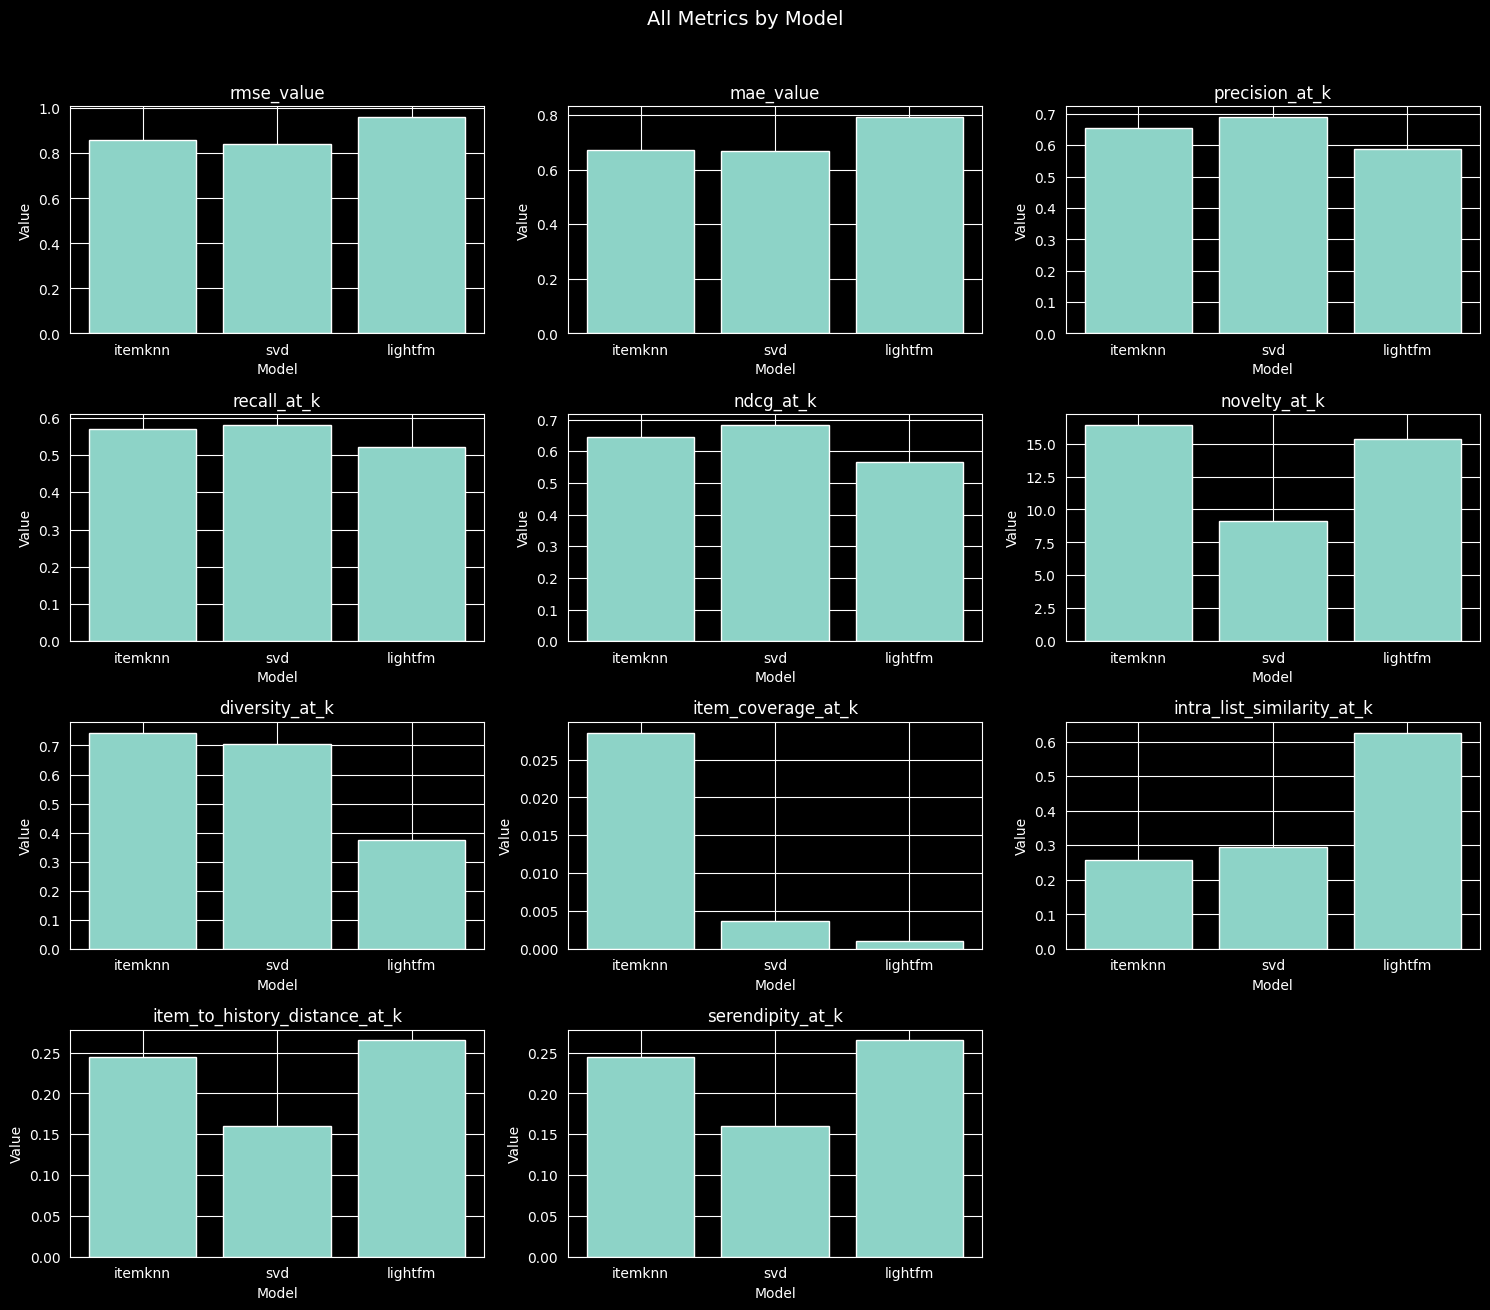

In [9]:
all_metric_columns = metrics_dataframe.columns.tolist()
number_of_metrics = len(all_metric_columns)
number_of_columns = 3
number_of_rows = int(np.ceil(number_of_metrics / number_of_columns))

figure, axes = plt.subplots(number_of_rows, number_of_columns, figsize=(15, number_of_rows * 3.2))
axes = np.atleast_1d(axes).flatten()

for index_value, metric_name in enumerate(all_metric_columns):
    axis = axes[index_value]
    metric_values = metrics_dataframe[metric_name]
    axis.bar(metrics_dataframe.index.tolist(), metric_values.tolist())
    axis.set_title(metric_name)
    axis.set_xlabel("Model")
    axis.set_ylabel("Value")

for index_value in range(number_of_metrics, len(axes)):
    axes[index_value].axis("off")

plt.suptitle("All Metrics by Model", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

## Graph 5: Normalized Heatmap

This normalizes each metric to [0, 1] so models are easier to compare together.

For RMSE and MAE, normalization is inverted because lower is better.

To avoid endpoint-heavy values (many near 0/1) with only a few models,
we use z-score normalization followed by a sigmoid transform.

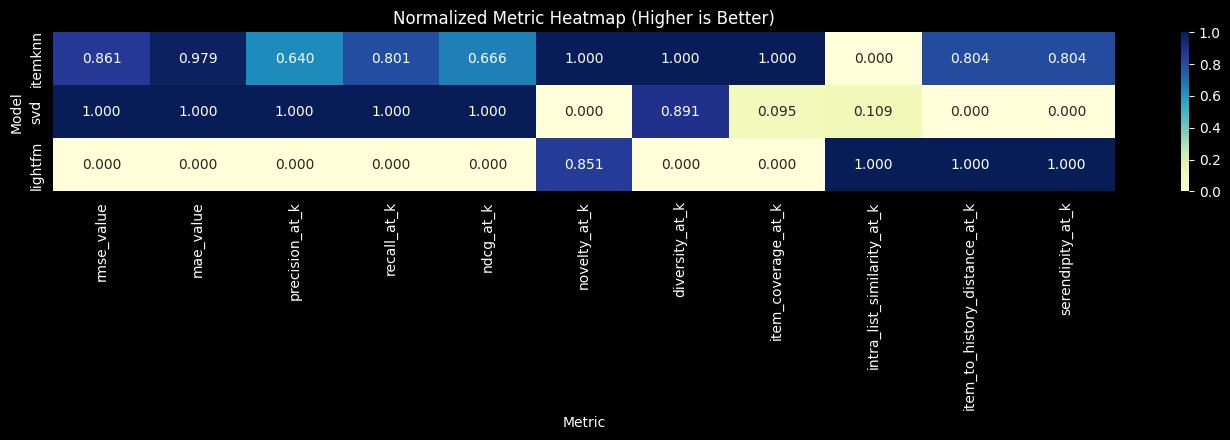

In [10]:
normalized_dataframe = metrics_dataframe.copy()
lower_is_better_metrics = {"rmse_value", "mae_value"}

for metric_name in normalized_dataframe.columns:
    metric_series = normalized_dataframe[metric_name].astype(float)

    # Flip lower-is-better metrics so larger is always better before scaling.
    if metric_name in lower_is_better_metrics:
        metric_series = -metric_series

    metric_mean_value = float(metric_series.mean())
    metric_std_value = float(metric_series.std(ddof=0))

    if metric_std_value <= 1e-12:
        normalized_values = pd.Series([0.5] * len(metric_series), index=metric_series.index)
    else:
        zscore_values = (metric_series - metric_mean_value) / metric_std_value
        normalized_values = 1.0 / (1.0 + np.exp(-zscore_values))

    normalized_dataframe[metric_name] = normalized_values

plt.figure(figsize=(14, 4.5))
sns.heatmap(normalized_dataframe, annot=True, cmap="YlGnBu", fmt=".3f")
plt.title("Normalized Metric Heatmap (Higher is Better)")
plt.xlabel("Metric")
plt.ylabel("Model")
plt.tight_layout()
plt.show()

## Graph 6: Aggregate Normalized Score

This computes a simple average over normalized metrics for one global view.

In [11]:
aggregate_scores = normalized_dataframe.mean(axis=1).sort_values(ascending=False)

plt.figure(figsize=(8, 4))
sns.barplot(x=aggregate_scores.index.tolist(), y=aggregate_scores.values.tolist())
plt.title("Average Normalized Score Across All Metrics")
plt.xlabel("Model")
plt.ylabel("Average normalized score")
plt.ylim(0.0, 1.0)
plt.tight_layout()
plt.show()

aggregate_scores

model_name
itemknn    0.777649
svd        0.554063
lightfm    0.350135
dtype: float64